# Análisis de Absentismo Laboral - RHHH

### Preguntas de negocio

> ¿Cuál es la magnitud del absentismo laboral en la empresa y cómo varía a lo largo del año?  
> ¿Cómo podemos anticiparnos para reforzar la planificación de recursos humanos y garantizar la continuidad operativa?

---
## 1. Import y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

In [2]:
CSV_PATH = r'..\Data\DatasetClean_2026-06-29.csv'

df = pd.read_csv(CSV_PATH)


 Excluímos del análisis solicitudes de absencia si Absenteeism_Hours = 0
 > Nota: el 90,7% de los registros con Absenteeism_Hours = 0 corresponden a  Disciplinary_Failure = 1 (39 de 43 casos).

In [3]:
n_antes = len(df)
df = df[df["Absenteeism_Hours"] != 0].copy()
n_despues = len(df)

print(f'Registros antes del filtro: {n_antes}')
print(f'Registros después del filtro: {n_despues}')
print(f'Registros omitidos: {n_antes - n_despues}')

Registros antes del filtro: 705
Registros después del filtro: 662
Registros omitidos: 43


In [4]:
# Diccionario meses para visualizaciones
MESOS = {
    0: 'Sin mes', 1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}

df['Month_Absence_Desc'] = df['Month_Absence'].map(MESOS)

---
## 2.Magnitud del absentismo

In [5]:
print('Estadística descriptiva de Absenteeism_Hours')
print(df["Absenteeism_Hours"].describe().round(2))
print(f'\nAsimetría (skewness): {df["Absenteeism_Hours"].skew():.2f}')
print(f'\nHoras totales de absentismo:   {df["Absenteeism_Hours"].sum():.0f} h')
print(f'Media por absencia:            {df["Absenteeism_Hours"].mean():.1f} h')
print(f'Mediana por absencia:          {df["Absenteeism_Hours"].median():.1f} h')


Estadística descriptiva de Absenteeism_Hours
count    662.00
mean       7.62
std       13.92
min        1.00
25%        2.00
50%        4.00
75%        8.00
max      120.00
Name: Absenteeism_Hours, dtype: float64

Asimetría (skewness): 5.47

Horas totales de absentismo:   5043 h
Media por absencia:            7.6 h
Mediana por absencia:          4.0 h


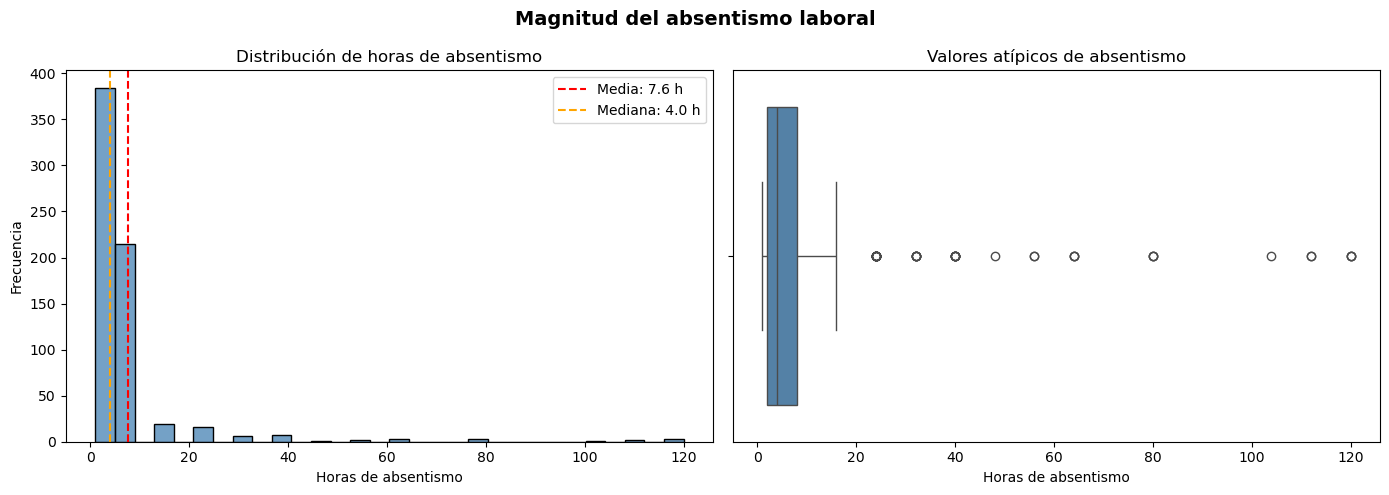

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Absenteeism_Hours"], bins=30, ax=axes[0], color='steelblue')
axes[0].axvline(df["Absenteeism_Hours"].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Media: {df["Absenteeism_Hours"].mean():.1f} h')
axes[0].axvline(df["Absenteeism_Hours"].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mediana: {df["Absenteeism_Hours"].median():.1f} h')
axes[0].set_title('Distribución de horas de absentismo')
axes[0].set_xlabel('Horas de absentismo')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

sns.boxplot(x=df["Absenteeism_Hours"], ax=axes[1], color='steelblue')
axes[1].set_title('Valores atípicos de absentismo')
axes[1].set_xlabel('Horas de absentismo')

plt.suptitle('Magnitud del absentismo laboral', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



In [7]:
# Horas totales por empleado
abs_per_empleat = df.groupby('ID_Employee')["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).round(1).sort_values('total_horas', ascending=False)


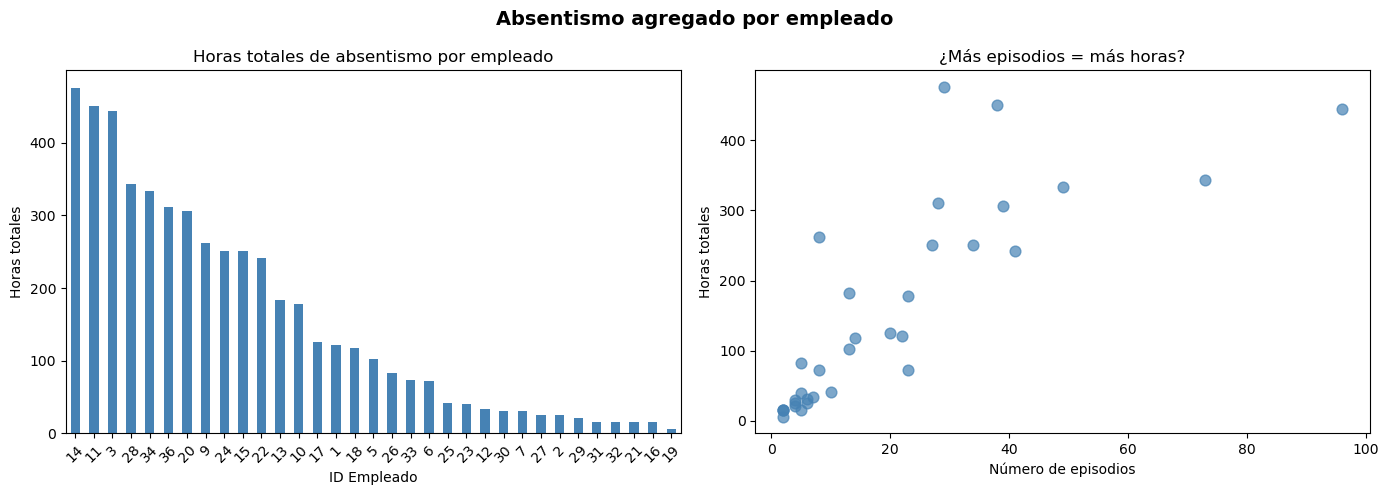

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

abs_per_empleat['total_horas'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Horas totales de absentismo por empleado')
axes[0].set_xlabel('ID Empleado')
axes[0].set_ylabel('Horas totales')
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(abs_per_empleat['num_absencias'], abs_per_empleat['total_horas'],
                alpha=0.7, color='steelblue', s=60)
axes[1].set_title('¿Más episodios = más horas?')
axes[1].set_xlabel('Número de episodios')
axes[1].set_ylabel('Horas totales')

plt.suptitle('Absentismo agregado por empleado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. Variación anual

**suma** de horas para ver el impacto total en la empresa, **mediana** para ver la magnitud de cada absencia.

**Nota**: se han excluido los registros con `Month_Absence = 0`.

In [9]:
df_mesos = df[df['Month_Absence'] != 0].copy()

---
#### Absentismo por mes

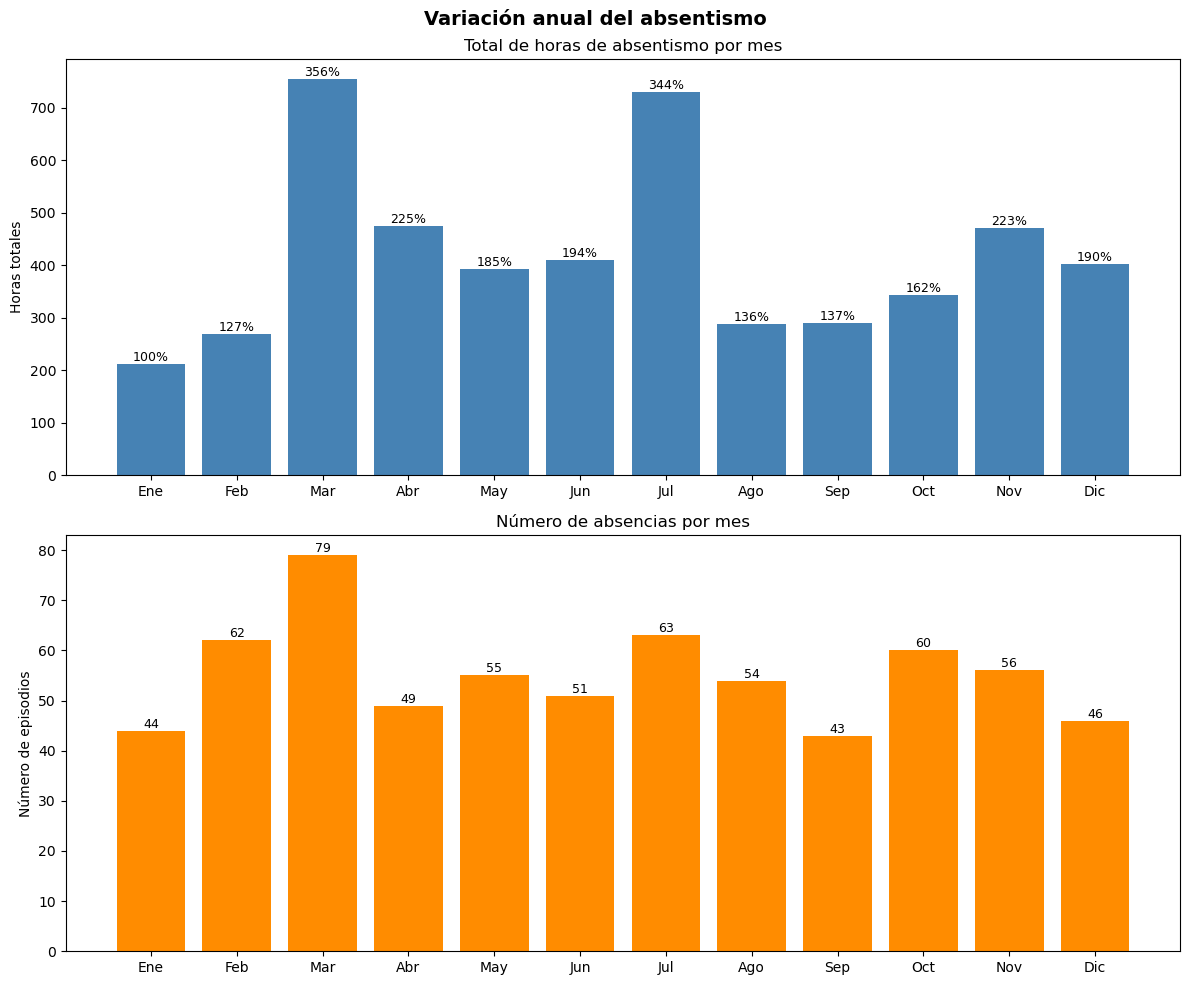

In [10]:
# Absentismo por mes
ordre_mesos = [MESOS[m] for m in range(1, 13)]

abs_mes = df_mesos.groupby('Month_Absence_Desc')["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).reindex(ordre_mesos).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

bars = axes[0].bar(abs_mes['Month_Absence_Desc'], abs_mes['total_horas'], color='steelblue')

# Calculamos el % de cada mes respecto al mes con menos horas
mes_min_horas = abs_mes['total_horas'].min()
etiquetas_pct = [f'{(v / mes_min_horas * 100):.0f}%' for v in abs_mes['total_horas']]
axes[0].bar_label(bars, labels=etiquetas_pct, fontsize=9)

axes[0].set_title('Total de horas de absentismo por mes')
axes[0].set_ylabel('Horas totales')

bars2 = axes[1].bar(abs_mes['Month_Absence_Desc'], abs_mes['num_absencias'], color='darkorange')
axes[1].bar_label(bars2, fontsize=9)
axes[1].set_title('Número de absencias por mes')
axes[1].set_ylabel('Número de episodios')

plt.suptitle('Variación anual del absentismo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

TOTAL HORAS:
- Meses con + horas con absencias: Marzo y Julio
- Meses con - horas con absencias: Enero y Febrero

El patrón de absentismo es claramente estacional:
- 2 picos marcados en marzo y julio
- comparado con los meses valle enero , tienen la mitad de episodios y 1 cuarta parte de las horas del mes pico (marzo).

---
#### Meses pico por horas totals absentismo

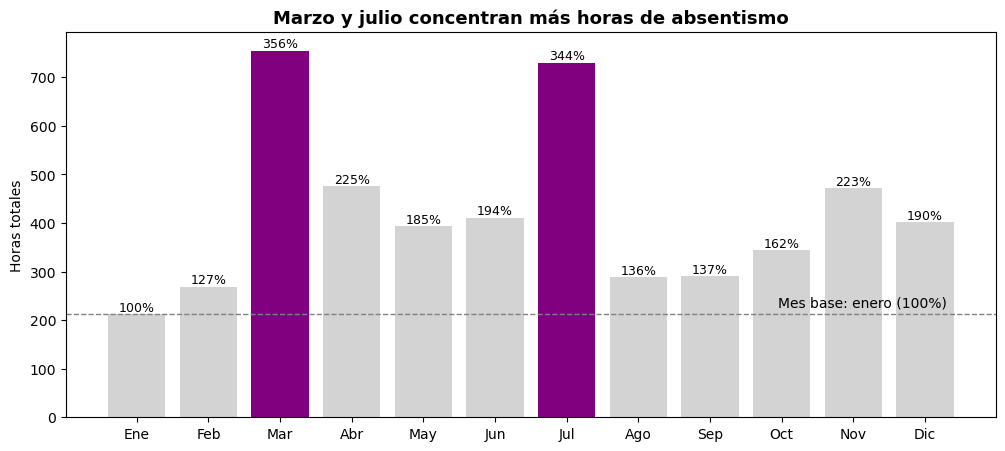

In [11]:
mes_min_horas = abs_mes['total_horas'].min()
etiquetas_pct = [f'{(v / mes_min_horas * 100):.0f}%' for v in abs_mes['total_horas']]
colors = ['purple' if mes in ['Mar', 'Jul'] else 'lightgray' for mes in abs_mes['Month_Absence_Desc']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(abs_mes['Month_Absence_Desc'], abs_mes['total_horas'], color=colors)
ax.bar_label(bars, labels=etiquetas_pct, fontsize=9)

# Línea de referencia: el mes mínimo (Enero)
ax.axhline(mes_min_horas, color='gray', linestyle='--', linewidth=1)
ax.text(11.3, mes_min_horas + 15, 'Mes base: enero (100%)', fontsize=10, color='black', ha='right')

ax.set_title('Marzo y julio concentran más horas de absentismo', fontsize=13, fontweight='bold')
ax.set_ylabel('Horas totales')

plt.show()

---
#### Variación horas acumuladas vs total absencias respecto a un mes típico

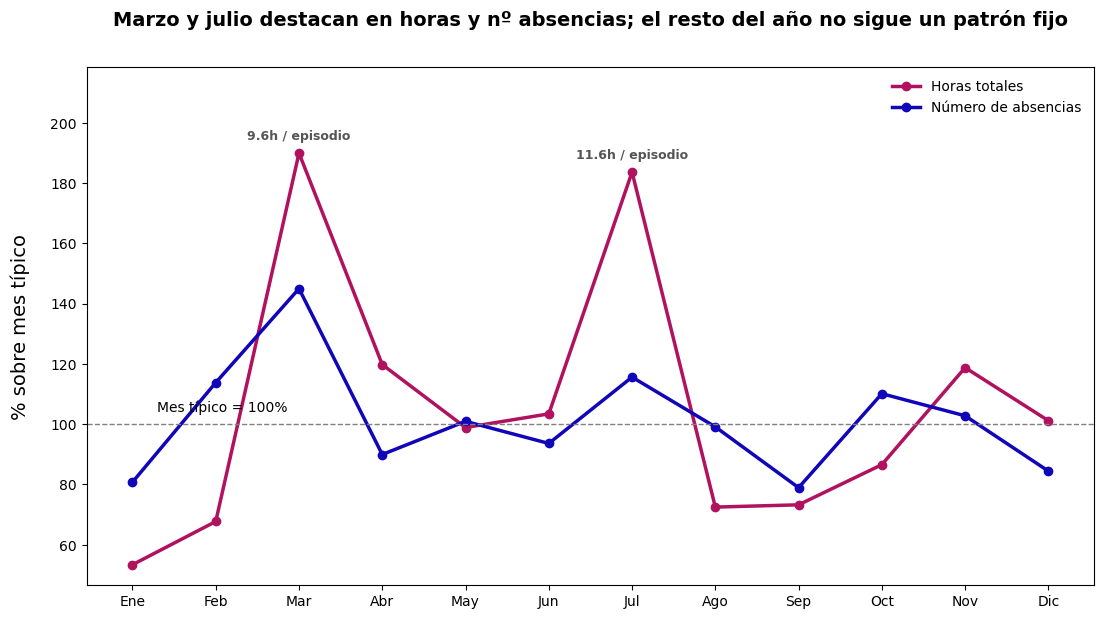

In [12]:
ordre_mesos = [MESOS[m] for m in range(1, 13)]
abs_mes = df_mesos.groupby('Month_Absence_Desc')["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).reindex(ordre_mesos).reset_index()

abs_mes['duracio_mitjana'] = (abs_mes['total_horas'] / abs_mes['num_absencias']).round(1)

horas_mediana = abs_mes['total_horas'].median()
episodios_mediana = abs_mes['num_absencias'].median()

pct_horas = abs_mes['total_horas'] / horas_mediana * 100
pct_episodios = abs_mes['num_absencias'] / episodios_mediana * 100

color_horas = '#B0125F'
color_ep = '#1105BA'

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(abs_mes['Month_Absence_Desc'], pct_horas, color=color_horas,
        marker='o', linewidth=2.5, markersize=6, label='Horas totales')
ax.plot(abs_mes['Month_Absence_Desc'], pct_episodios, color=color_ep,
        marker='o', linewidth=2.5, markersize=6, label='Número de absencias')

ax.axhline(100, color='gray', linestyle='--', linewidth=1)
ax.text(0.3, 104, 'Mes típico = 100%', fontsize=10, color='black')

for mes in ['Mar', 'Jul']:
    i = abs_mes[abs_mes['Month_Absence_Desc'] == mes].index[0]
    duracion = abs_mes['duracio_mitjana'][i]
    y_max = max(pct_horas[i], pct_episodios[i])
    ax.annotate(f'{duracion}h / episodio', (mes, y_max), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9,
                color='#555555', fontweight='bold')

ax.set_ylabel('% sobre mes típico', fontsize=14, labelpad=15)
ax.set_ylim(top=pct_horas.max() * 1.15)
ax.legend(loc='upper right', frameon=False)

plt.title('Marzo y julio destacan en horas y nº absencias; el resto del año no sigue un patrón fijo',
          fontsize=14, fontweight='bold', pad=30)
plt.subplots_adjust(top=0.85)
plt.show()

> Coinciden en los dos picos (Mar, Jul); fuera de ellos, el patrón es más irregular

---
#### Total de absencias vs. duración por mes

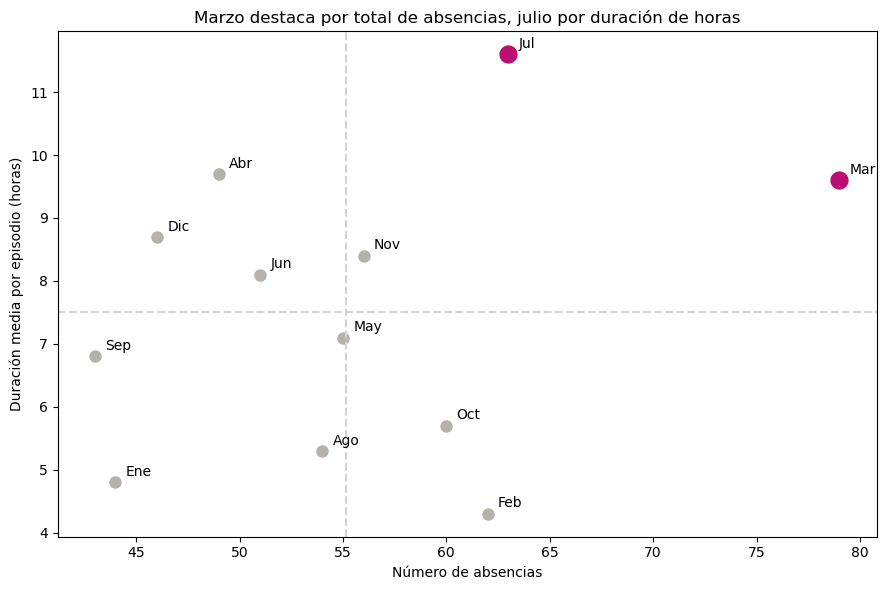

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

meses_destacar = ['Mar', 'Jul']

# Dibujamos un punto por cada mes, uno a uno
for i in range(len(abs_mes)):
    mes = abs_mes['Month_Absence_Desc'][i]
    x = abs_mes['num_absencias'][i]
    y = abs_mes['duracio_mitjana'][i]

    if mes in meses_destacar:
        color = '#BC0E70'
        tamano = 200
    else:
        color = '#B4B2A9'
        tamano = 100

    ax.scatter(x, y, color=color, s=tamano, edgecolors='white', linewidth=1)
    ax.text(x + 0.5, y + 0.1, mes, fontsize=10)

# Líneas de referencia (medias generales)
media_episodios = abs_mes['num_absencias'].mean()
media_duracion = abs_mes['duracio_mitjana'].mean()
ax.axvline(media_episodios, color='lightgray', linestyle='--')
ax.axhline(media_duracion, color='lightgray', linestyle='--')

ax.set_xlabel('Número de absencias')
ax.set_ylabel('Duración media por episodio (horas)')
ax.set_title('Marzo destaca por total de absencias, julio por duración de horas')

plt.tight_layout()
plt.show()

---
#### Absentismo por estación del año

<span style="color:red; font-weight:bold;">VARIACIÓN HASTA QUE LA COLUMNA SEASON ESTÉ CLEAN</span>

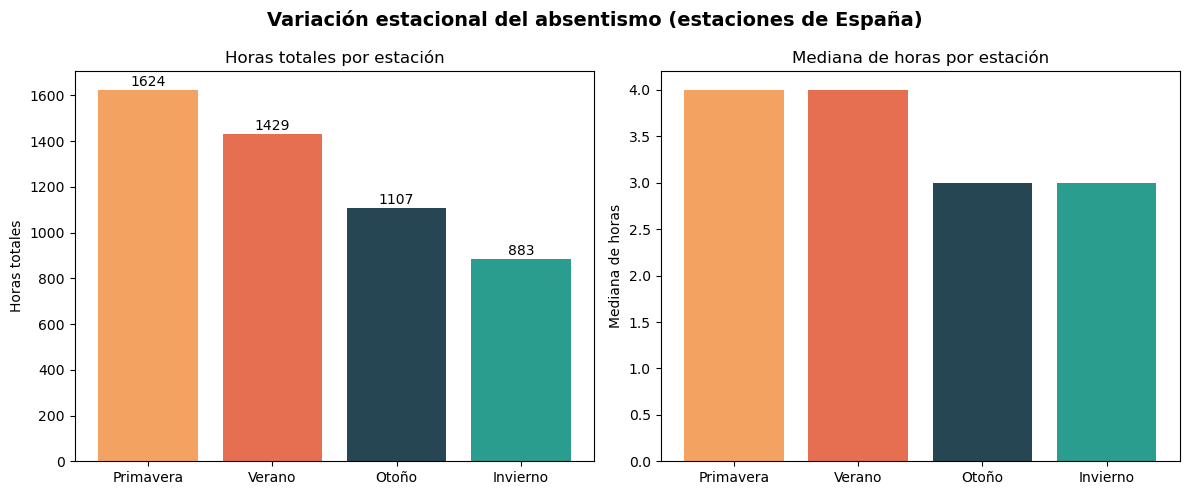

Season_Desc_ES  total_horas  num_absencias  mediana_horas
     Primavera         1624            183            4.0
        Verano         1429            168            4.0
         Otoño         1107            159            3.0
      Invierno          883            152            3.0


In [14]:
# Diccionario de estaciones según el mes (convención meteorológica de España)
ESTACION_MES = {
    0: 'Sin mes',
    1: 'Invierno', 2: 'Invierno', 12: 'Invierno',
    3: 'Primavera', 4: 'Primavera', 5: 'Primavera',
    6: 'Verano', 7: 'Verano', 8: 'Verano',
    9: 'Otoño', 10: 'Otoño', 11: 'Otoño'
}

df['Season_Desc_ES'] = df['Month_Absence'].map(ESTACION_MES)

# Absentismo por estación (usando nuestra propia clasificación)
abs_estacio = df.groupby('Season_Desc_ES')["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).reset_index().sort_values('total_horas', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_est = ['#f4a261', '#e76f51', '#264653', '#2a9d8f']
bars = axes[0].bar(abs_estacio['Season_Desc_ES'], abs_estacio['total_horas'], color=colors_est)
for bar, val in zip(bars, abs_estacio['total_horas']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(val)), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Horas totales por estación')
axes[0].set_ylabel('Horas totales')

axes[1].bar(abs_estacio['Season_Desc_ES'], abs_estacio['mediana_horas'], color=colors_est)
axes[1].set_title('Mediana de horas por estación')
axes[1].set_ylabel('Mediana de horas')

plt.suptitle('Variación estacional del absentismo (estaciones de España)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(abs_estacio[['Season_Desc_ES', 'total_horas', 'num_absencias', 'mediana_horas']].to_string(index=False))

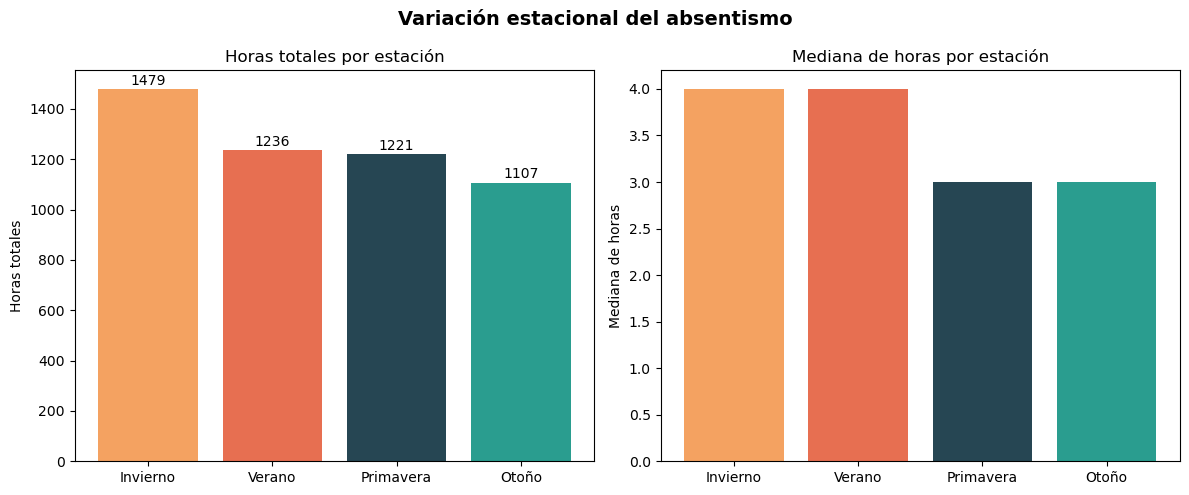

Season_Desc  total_horas  num_absencias  mediana_horas
   Invierno         1479            163            4.0
     Verano         1236            161            4.0
  Primavera         1221            168            3.0
      Otoño         1107            170            3.0


In [15]:
# Absentismo por estación
abs_estacio = df.groupby('Season_Desc')["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).reset_index().sort_values('total_horas', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_est = ['#f4a261', '#e76f51', '#264653', '#2a9d8f']
bars = axes[0].bar(abs_estacio['Season_Desc'], abs_estacio['total_horas'], color=colors_est)
for bar, val in zip(bars, abs_estacio['total_horas']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(val)), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Horas totales por estación')
axes[0].set_ylabel('Horas totales')

axes[1].bar(abs_estacio['Season_Desc'], abs_estacio['mediana_horas'], color=colors_est)
axes[1].set_title('Mediana de horas por estación')
axes[1].set_ylabel('Mediana de horas')

plt.suptitle('Variación estacional del absentismo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(abs_estacio[['Season_Desc', 'total_horas', 'num_absencias', 'mediana_horas']].to_string(index=False))

---
#### Absentismo por día de la semana

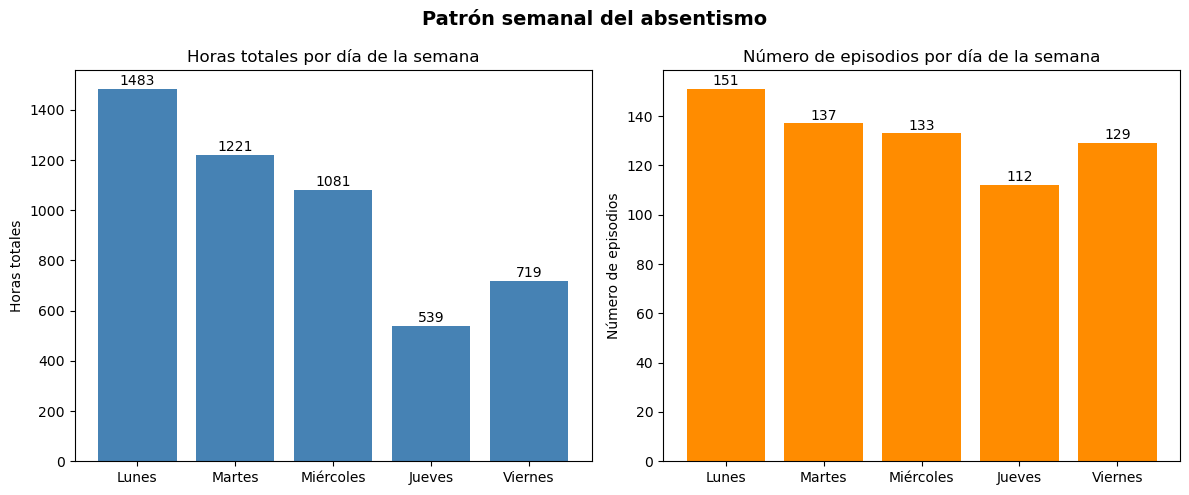

In [16]:

ordre_dies = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']

abs_dia = df.groupby('Day_Week_Desc')["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).reset_index()

# Reordenar según día de la semana
ordre_reals = [d for d in ordre_dies if d in abs_dia['Day_Week_Desc'].values]
abs_dia = abs_dia.set_index('Day_Week_Desc').reindex(ordre_reals).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(abs_dia['Day_Week_Desc'], abs_dia['total_horas'], color='steelblue')
for bar, val in zip(bars, abs_dia['total_horas']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(int(val)), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Horas totales por día de la semana')
axes[0].set_ylabel('Horas totales')

bars2 = axes[1].bar(abs_dia['Day_Week_Desc'], abs_dia['num_absencias'], color='darkorange')
for bar, val in zip(bars2, abs_dia['num_absencias']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(val)), ha='center', va='bottom', fontsize=10)
axes[1].set_title('Número de episodios por día de la semana')
axes[1].set_ylabel('Número de episodios')

plt.suptitle('Patrón semanal del absentismo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Resultados: mismo patrón semanal en total de absencias y total de horas. Pico al inicio de la semana, desciende hasta el mínimo el jueves y vuelve a subir ligeramente.

---
#### Heatmap: mes x día de la semana
¿Combinaciones de mes-día críticas?

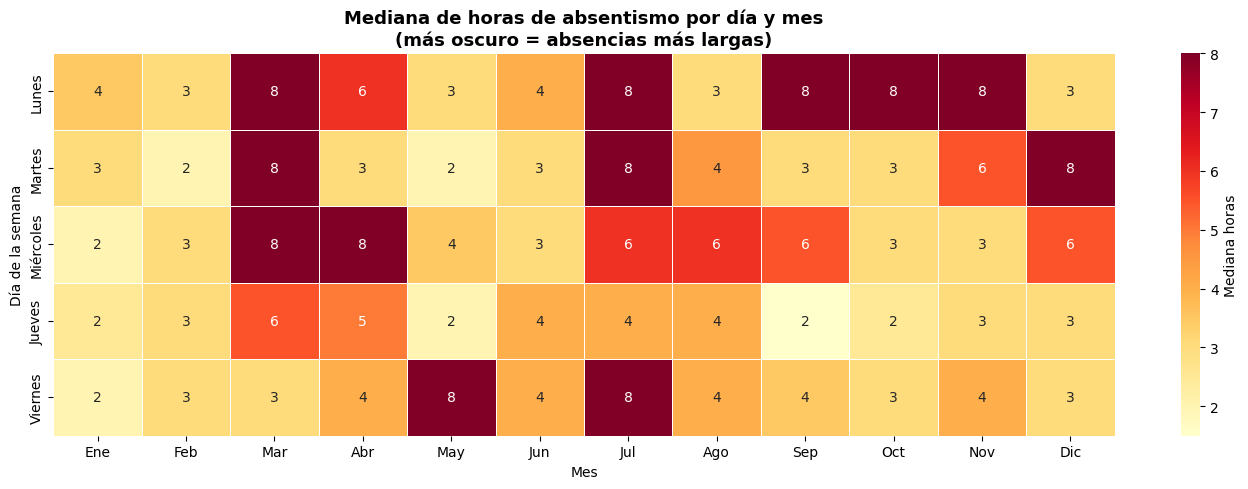

In [17]:
pivot = df_mesos.pivot_table(
    values="Absenteeism_Hours",
    index='Day_Week_Desc',
    columns='Month_Absence_Desc',
    aggfunc='median'
)

ordre_dies_pivot = [d for d in ordre_dies if d in pivot.index]
pivot = pivot.reindex(index=ordre_dies_pivot,
                      columns=[m for m in ordre_mesos if m in pivot.columns])

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mediana horas'})
plt.title('Mediana de horas de absentismo por día y mes\n(más oscuro = absencias más largas)',
          fontsize=13, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Día de la semana')
plt.tight_layout()
plt.show()

---
## 4. Análisis por motivo

tres grupos:

- **Enfermedad diagnosticada (ICD 1-21):** enfermedades según la clasificación internacional. Difíciles de anticipar / prevenir desde RRHH.
- **Atención sanitaria programada y otros (ICD 22-25, 27-28):** consultas médicas, fisioterapia, laboratorio, donación de sangre, etc. Sí son planificables por la antelación extra.
- **Ausencia injustificada (ICD 26):** de naturaleza distinta, no sanitaria — se trata por separado.

In [18]:
# Clasificación motivos
def classify_group(codi):
    if codi == 0:
        return 'Sin código'
    elif codi <= 21:
        return 'Enfermedad diagnosticada (ICD 1-21)'
    elif codi == 26:
        return 'Ausencia injustificada'
    else:
        return 'Atención sanitaria programada y otros (ICD 22-28)'


In [19]:
df['reason_group'] = df['Reason_Absence'].apply(classify_group)

---
### Tabla horas según motivo

In [20]:

abs_motiu = df.groupby(['Reason_Absence', 'Reason_Absence_Desc', 'reason_group'])["Absenteeism_Hours"].agg(
    total_horas='sum',
    num_absencias='count',
    mediana_horas='median'
).reset_index().sort_values('total_horas', ascending=False)

print('Top motivos por horas totales')
print()
print(abs_motiu[['Reason_Absence_Desc', 'reason_group', 'total_horas', 'num_absencias', 'mediana_horas']].to_string(index=False))

Top motivos por horas totales

                                 Reason_Absence_Desc                                      reason_group  total_horas  num_absencias  mediana_horas
         Enfermedades del sistema musculoesquelético               Enfermedad diagnosticada (ICD 1-21)          842             55            8.0
                          Lesiones y envenenamientos               Enfermedad diagnosticada (ICD 1-21)          729             40            8.0
                                     Consulta médica Atención sanitaria programada y otros (ICD 22-28)          408            142            2.0
                                     Consulta dental Atención sanitaria programada y otros (ICD 22-28)          329            108            2.0
                  Enfermedades del sistema digestivo               Enfermedad diagnosticada (ICD 1-21)          297             26            8.0
                             Seguimiento de paciente Atención sanitaria programada y otros (I

### Gráfico horas según motivo

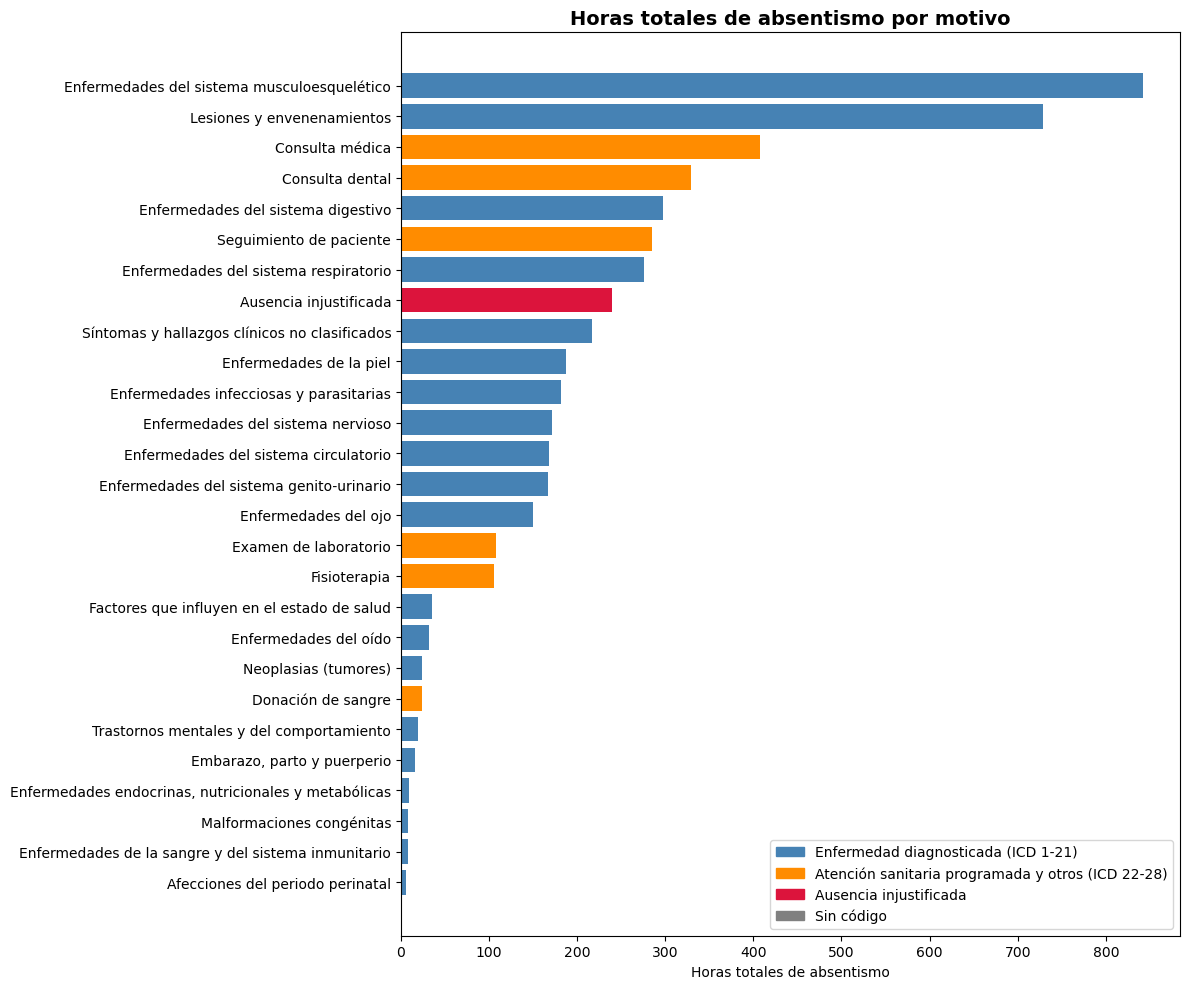

In [21]:
color_map = {
    'Enfermedad diagnosticada (ICD 1-21)': 'steelblue',
    'Atención sanitaria programada y otros (ICD 22-28)': 'darkorange',
    'Ausencia injustificada': 'crimson',
    'Sin código': 'grey'
}
colors = abs_motiu['reason_group'].map(color_map)

plt.figure(figsize=(12, 10))
plt.barh(abs_motiu['Reason_Absence_Desc'], abs_motiu['total_horas'], color=colors)
plt.xlabel('Horas totales de absentismo')
plt.title('Horas totales de absentismo por motivo', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

llegenda = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
plt.legend(handles=llegenda, loc='lower right')
plt.tight_layout()
plt.show()

---
### Proporción enfermedades médicas ICD vs otros

 Proporción por tipo de motivo (horas totales) 
                                     reason_group  total_horas  pct
Atención sanitaria programada y otros (ICD 22-28)         1260 25.0
                           Ausencia injustificada          240  4.8
              Enfermedad diagnosticada (ICD 1-21)         3543 70.3


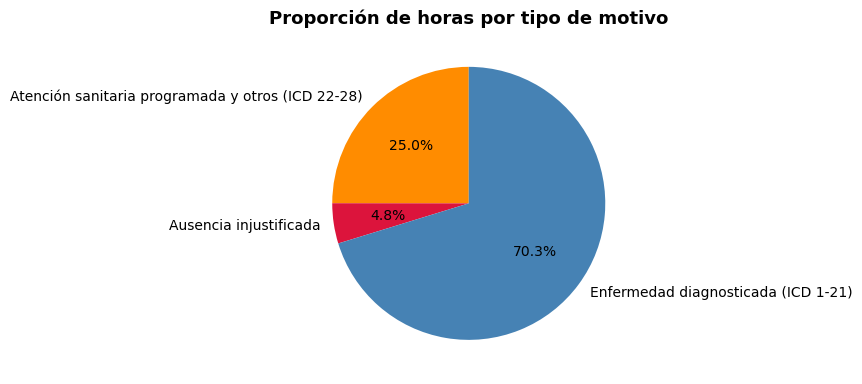

In [22]:

resum = abs_motiu.groupby('reason_group')['total_horas'].sum().reset_index()
resum['pct'] = (resum['total_horas'] / resum['total_horas'].sum() * 100).round(1)

print(' Proporción por tipo de motivo (horas totales) ')
print(resum.to_string(index=False))

plt.figure(figsize=(7, 5))
plt.pie(resum['total_horas'], labels=resum['reason_group'],
        autopct='%1.1f%%',
        colors=[color_map.get(t, 'grey') for t in resum['reason_group']],
        startangle=90)
plt.title('Proporción de horas por tipo de motivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Heatmap de motivos planificables por mes (atención sanitaria programada)

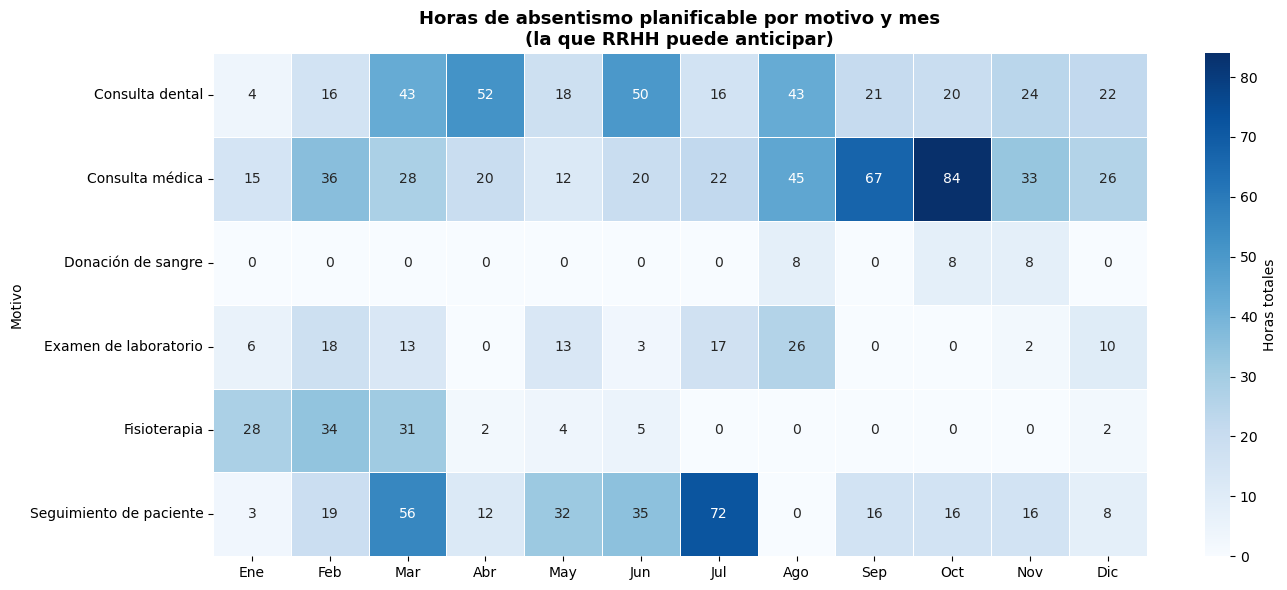

In [27]:

df_planificable = df_mesos[(df_mesos['Reason_Absence'] >= 22) & (df_mesos['Reason_Absence'] != 26)].copy()

pivot_nm = df_planificable.pivot_table(
    values="Absenteeism_Hours",
    index='Reason_Absence_Desc',
    columns='Month_Absence_Desc',
    aggfunc='sum',
    fill_value=0
)
pivot_nm = pivot_nm[[m for m in ordre_mesos if m in pivot_nm.columns]]

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_nm, annot=True, fmt='g', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Horas totales'})
plt.title('Horas de absentismo planificable por motivo y mes\n(la que RRHH puede anticipar)',
          fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Motivo')
plt.tight_layout()
plt.show()

## 5. Relación entre absentismo y variables laborales
Variables laborales (carga de trabajo, distancia al trabajo, antigüedad...) relacionadas con la cantidad de horas de absentismo.

### **Justificación técnica uso Spearman y no Pearson**

Distribución muy sesgada a la derecha (muchas absencias cortas y unas pocas muy largas)  
Se usará Spearman para las correlaciones (más robusto pq trabaja con rango en vez de valores absolutos)  
Se usará principalmente la mediana como medida central.

### **Limitación importante a tener en cuenta:**  
Los registros de absencia no son x personas independientes. Son 36 empleados con múltiples ausencias cada uno. Esto puede afectar artificialmente los coeficientes de correlación.

In [24]:
vars_laborals = [
    'Absenteeism_Hours', 'Work_load_Average_Day', 'Hit_Target',
    'Transportation_Expense', 'Distance_Residence_Work',
    'Service_Time', 'Age'
]

corr_spearman = df[vars_laborals].corr(method='spearman')
corr_abs = corr_spearman['Absenteeism_Hours'].drop('Absenteeism_Hours').sort_values(ascending=False)

print('Correlación de Spearman con Absenteeism_Hours')
print(corr_abs.round(3))

Correlación de Spearman con Absenteeism_Hours
Transportation_Expense     0.217
Work_load_Average_Day      0.032
Hit_Target                -0.002
Distance_Residence_Work   -0.014
Service_Time              -0.018
Age                       -0.021
Name: Absenteeism_Hours, dtype: float64


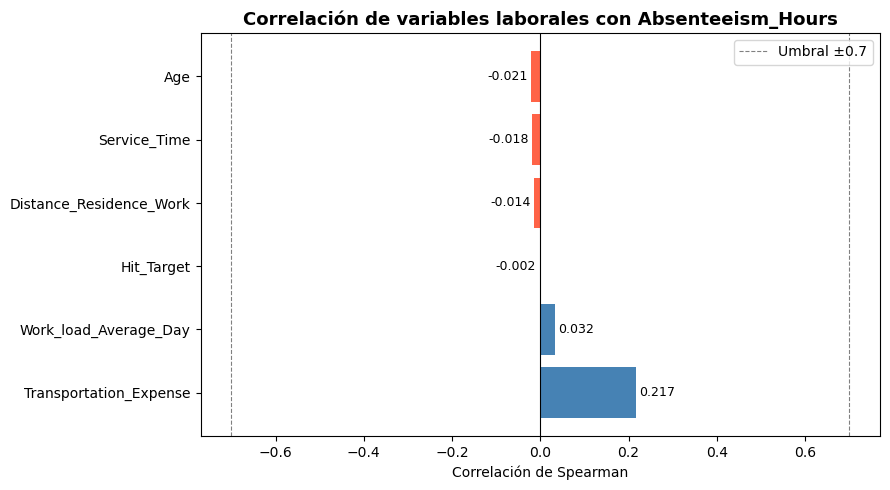

In [25]:
colors_corr = ['steelblue' if v >= 0 else 'tomato' for v in corr_abs]

plt.figure(figsize=(9, 5))
bars = plt.barh(corr_abs.index, corr_abs.values, color=colors_corr)
plt.axvline(0, color='black', linewidth=0.8)
plt.axvline(0.7, color='grey', linewidth=0.8, linestyle='--', label='Umbral ±0.7')
plt.axvline(-0.7, color='grey', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, corr_abs.values):
    offset = 0.008 if val >= 0 else -0.008
    plt.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)
plt.xlabel('Correlación de Spearman')
plt.title('Correlación de variables laborales con Absenteeism_Hours', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


---
## 6. Conclusiones y recomendaciones de negocio

In [26]:
total_horas = df["Absenteeism_Hours"].sum()
mediana_ep = df["Absenteeism_Hours"].median()
num_empleats = df['ID_Employee'].nunique()
hores_per_emp = total_horas / num_empleats

mes_max = abs_mes.loc[abs_mes['total_horas'].idxmax(), 'Month_Absence_Desc']
mes_min = abs_mes.loc[abs_mes['total_horas'].idxmin(), 'Month_Absence_Desc']
est_max = abs_estacio.loc[abs_estacio['total_horas'].idxmax(), 'Season_Desc']
dia_max_ep = abs_dia.loc[abs_dia['num_absencias'].idxmax(), 'Day_Week_Desc']
motiu_top = abs_motiu.iloc[0]['Reason_Absence_Desc']

print('   RESUMEN EJECUTIVO — ABSENTISMO LABORAL')
print(f'  Horas totales de absentismo:        {total_horas:,.0f} h')
print(f'  Mediana por episodio:               {mediana_ep:.0f} h')
print(f'  Horas totales por empleado:         {hores_per_emp:.0f} h')
print(f'  Mes con más absentismo:             {mes_max}')
print(f'  Mes con menos absentismo:           {mes_min}')
print(f'  Día con más episodios:              {dia_max_ep}')
print(f'  Motivo principal (horas):           {motiu_top}')


   RESUMEN EJECUTIVO — ABSENTISMO LABORAL
  Horas totales de absentismo:        5,043 h
  Mediana por episodio:               4 h
  Horas totales por empleado:         153 h
  Mes con más absentismo:             Mar
  Mes con menos absentismo:           Ene
  Día con más episodios:              Lunes
  Motivo principal (horas):           Enfermedades del sistema musculoesquelético


In [41]:
def generar_calendario_generico(pivot):
    """
    Genera una tabla con todas las combinaciones de mes y día laborable,
    indicando el nivel de absentismo previsto según el patrón histórico.
    Parámetros:
        pivot (DataFrame): tabla mes x día con la mediana de horas (heatmap)
    Return:
        DataFrame: una fila por combinación mes-día, con sus horas previstas
    """
    dias_laborables = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']
    filas = []

    for mes in pivot.columns:
        for dia in dias_laborables:
            if dia in pivot.index:
                horas = pivot.loc[dia, mes]
                filas.append({
                    'Mes': mes,
                    'Día_semana': dia,
                    'Horas_previstas': horas
                })

    return pd.DataFrame(filas)

def clasificar_riesgo_dia(horas, mediana_general):
    """
    Clasifica el riesgo de un día concreto comparándolo con la mediana general.
    Parámetros:
        horas (float): horas previstas para ese día
        mediana_general (float): mediana de todas las combinaciones mes-día
    Return: str: 'Alto', 'Medio' o 'Bajo'
    """
    if horas >= mediana_general * 1.5:
        return 'Alto'
    elif horas >= mediana_general:
        return 'Medio'
    else:
        return 'Bajo'



In [42]:
mediana_general = calendario_generico['Horas_previstas'].median()
calendario_generico['Riesgo'] = calendario_generico['Horas_previstas'].apply(
    lambda h: clasificar_riesgo_dia(h, mediana_general)
)

print(calendario_generico.sort_values('Horas_previstas', ascending=False).to_string(index=False))


Mes Día_semana  Horas_previstas Riesgo
Jul      Lunes              8.0   Alto
Sep      Lunes              8.0   Alto
Dic     Martes              8.0   Alto
May    Viernes              8.0   Alto
Jul    Viernes              8.0   Alto
Nov      Lunes              8.0   Alto
Oct      Lunes              8.0   Alto
Abr  Miércoles              8.0   Alto
Mar      Lunes              8.0   Alto
Mar     Martes              8.0   Alto
Mar  Miércoles              8.0   Alto
Jul     Martes              8.0   Alto
Jul  Miércoles              6.0   Alto
Ago  Miércoles              6.0   Alto
Abr      Lunes              6.0   Alto
Mar     Jueves              5.5   Alto
Sep  Miércoles              5.5   Alto
Nov     Martes              5.5   Alto
Dic  Miércoles              5.5   Alto
Abr     Jueves              5.0  Medio
Ago     Martes              4.5  Medio
Ago    Viernes              4.0  Medio
Abr    Viernes              4.0  Medio
Ago     Jueves              4.0  Medio
Nov    Viernes           

## RECOMENDACIONES DE NEGOCIO:

## PREGUNTAS OBJETIVO:
### Magnitud absentismo:
### Evolución anual absentismo:
### Cómo anticiparse para reforzar planificación RRHH
Para garantizar la continuidad operativa podemos anticiparnos reforzando la planificación de recursos humanos en la combinación de momentos detectados como más vulnerables (con más absencias), que son:

- MESES:
- COMBINACIÓN MES - DÍA


- Email recordatorio a empleados con objetivo buenas prácticas para tramitar solicitud absencia programada lo antes posible. 

1. PLANIFICACIÓN ESTACIONAL
   XXXXXXXXXXXXXXXXXXX

2. PATRÓN SEMANAL


3. AUSENCIAS PLANIFICABLES


LIMITACIONES DEL ANÁLISIS ???

- RECOMENDACIONES EXTRA:
Dado que el motivo TOP de ausencia son enfermedades del sistema musculoesquelético (842h, 55 ausencias):
   - Recordatorio formación Prevención Riesgos Laborales en educación postural para el manejo de pesos
   - Explorar opciones para facilitar servicios de fisio empresa
